# Упражнение 2.3 

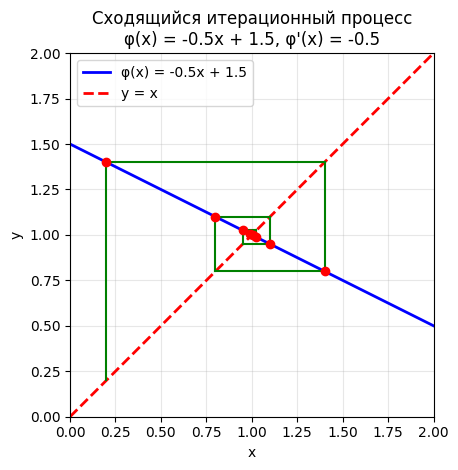

Решение уравнения x·sin(x) - 1 = 0
Метод простой итерации, точность 10^-5

Итерация 1: x = 1.18839511
Итерация 2: x = 1.07785184
Итерация 3: x = 1.13514686
Итерация 4: x = 1.10302696
Итерация 5: x = 1.12035241
Итерация 6: x = 1.11079771
Итерация 7: x = 1.11600528
Итерация 8: x = 1.11314838
Итерация 9: x = 1.11471013
Итерация 10: x = 1.11385471
Итерация 11: x = 1.11432275
Итерация 12: x = 1.11406652
Итерация 13: x = 1.11420675
Итерация 14: x = 1.11412999
Итерация 15: x = 1.11417200
Итерация 16: x = 1.11414901
Итерация 17: x = 1.11416159
Итерация 18: x = 1.11415470

Приближённое значение корня: 1.11415470
Проверка: x * sin(x) - 1 = -0.00000338


In [ ]:


import math
import numpy as np
import matplotlib.pyplot as plt

# === Задание 1 ===
# Демонстрация сходящегося итерационного процесса

def phi(x):
    """Функция для итерационного процесса"""
    return -0.5 * x + 1.5

# Создаем точки для построения графиков
x_koord = np.linspace(0, 2, 100)
y_phi = phi(x_koord)

# Строим график функции и прямой y = x
plt.plot(x_koord, y_phi, 'b-', linewidth=2, label='φ(x) = -0.5x + 1.5')
plt.plot(x_koord, x_koord, 'r--', linewidth=2, label='y = x')
plt.grid(True, alpha=0.3)

# Начальное приближение
x_nachalnoe = 0.2
x_tochki = [x_nachalnoe]
kolichestvo_iteraciy = 8

# Выполняем итерации и строим "лесенку"
for i in range(kolichestvo_iteraciy):
    x_sleduyushee = phi(x_tochki[-1])
    x_tochki.append(x_sleduyushee)
    
    # Рисуем вертикальную и горизонтальную линии для каждого шага
    plt.plot([x_tochki[i], x_tochki[i]], [x_tochki[i], x_tochki[i+1]], 'g-', linewidth=1.5)
    plt.plot([x_tochki[i], x_tochki[i+1]], [x_tochki[i+1], x_tochki[i+1]], 'g-', linewidth=1.5)
    plt.plot(x_tochki[i], phi(x_tochki[i]), 'ro', markersize=6)

# Оформление графика
plt.title(f'Сходящийся итерационный процесс\nφ(x) = -0.5x + 1.5, φ\'(x) = -0.5')
plt.xlabel('x'), plt.ylabel('y')
plt.legend()
plt.axis([0, 2, 0, 2])
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()


# === Задание 2 ===
# Решение уравнения x·sin(x) - 1 = 0 методом простой итерации

print("Решение уравнения x·sin(x) - 1 = 0")
print("Метод простой итерации, точность 10^-5")
print()

def phi_iter(x):
    """Функция для итерационного процесса: x = 1/sin(x)"""
    return 1 / np.sin(x)

# Начальное приближение
x_tekushiy = 1

# Выполняем итерации до достижения точности
for nomer_iteracii in range(1, 20):
    x_noviy = phi_iter(x_tekushiy)
    print(f"Итерация {nomer_iteracii}: x = {x_noviy:.8f}")
    
    # Проверяем достигнута ли нужная точность
    if abs(x_noviy - x_tekushiy) < 0.00001:
        print()
        print(f"Приближённое значение корня: {x_noviy:.8f}")
        print(f"Проверка: x * sin(x) - 1 = {x_noviy * np.sin(x_noviy) - 1:.8f}")
        break
    x_tekushiy = x_noviy

# Упражнение 2.5 

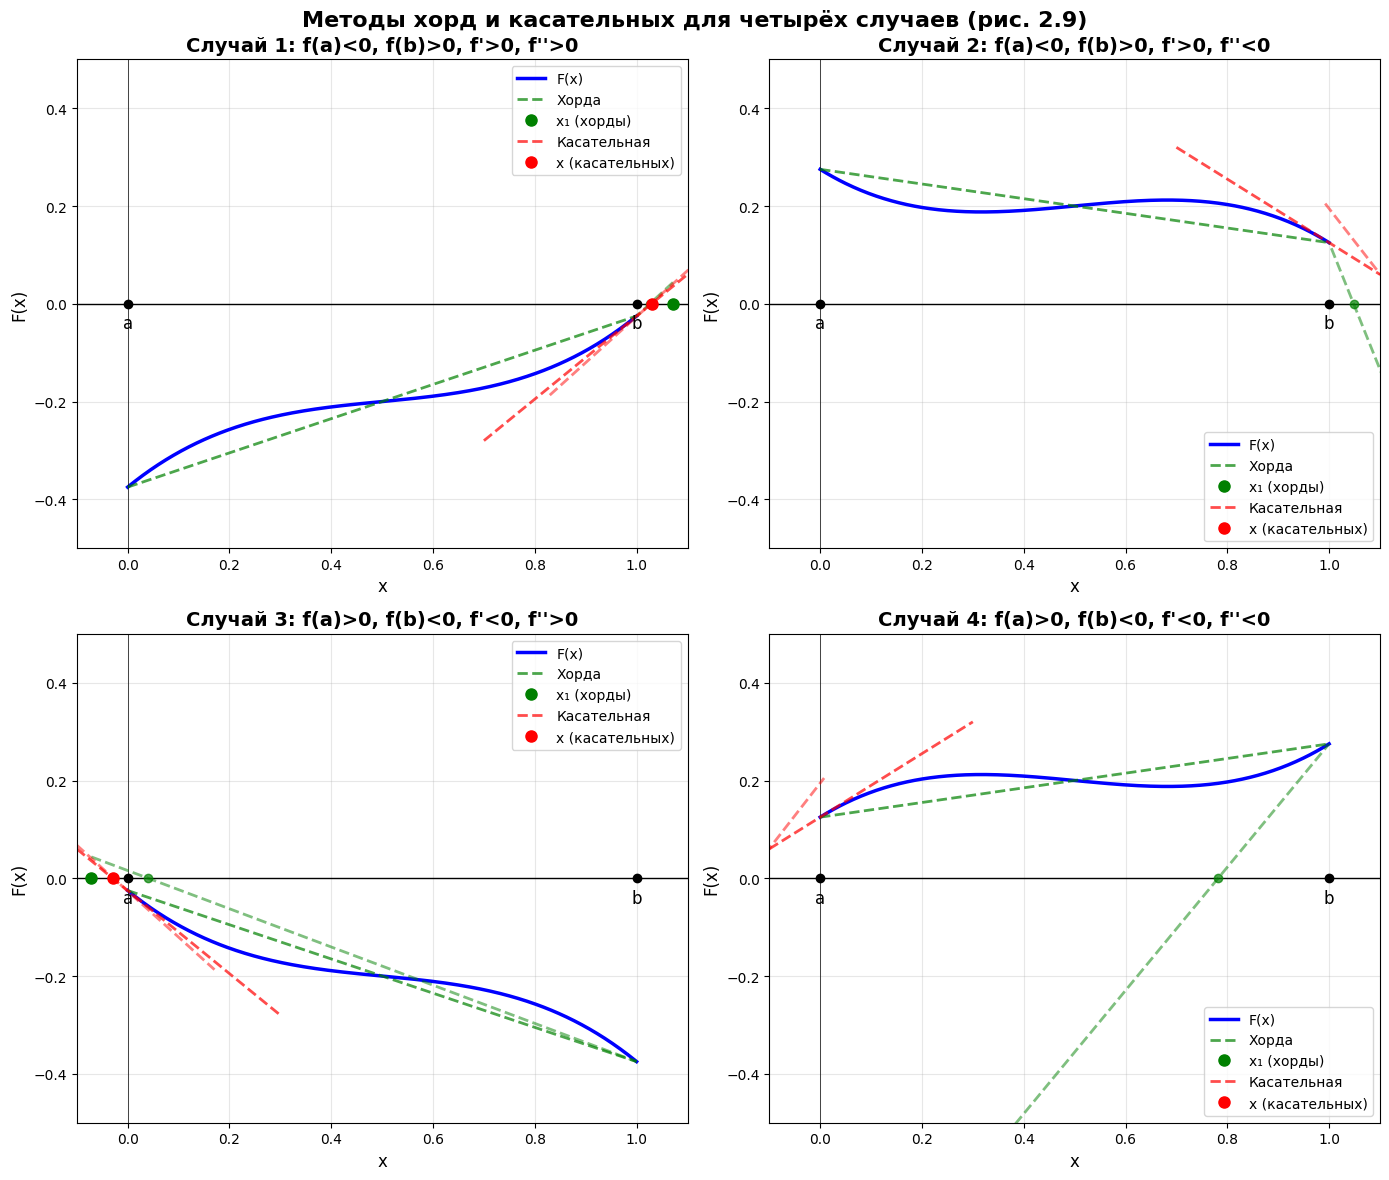

--- Комбинированный метод хорд и касательных ---
Уравнение: x³ + 3x² - 24x + 1 = 0
Отрезок: [0, 1]
Точность: 1e-06

----------------------------------------------------------------------
Итерация |   Метод хорд    |  Метод касат.   |   |x_хорд - x_кас|   |    f(x_сред)   
----------------------------------------------------------------------
       1 |      0.05000000 |      0.04166667 |         0.0083333333 |       -9.36e-02
       2 |      0.04188930 |      0.04188906 |         0.0000002448 |       -2.75e-06

Приближённое значение корня: 0.04188918
Значение функции в корне: -2.75e-06


In [ ]:

import math
import numpy as np
import matplotlib.pyplot as plt

# === Задание 1 ===
# Иллюстрация методов хорд и касательных для разных случаев

# Случай 1: f(a) < 0, f(b) > 0, производная > 0, вторая производная > 0
def sluchay_1(x):
    """Функция для первого случая"""
    return (x - 0.5)**3 + 0.1*(x - 0.5) - 0.2

# Случай 2: f(a) < 0, f(b) > 0, производная > 0, вторая производная < 0
def sluchay_2(x):
    """Функция для второго случая"""
    return -((x - 0.5)**3) + 0.1*(x - 0.5) + 0.2

# Случай 3: f(a) > 0, f(b) < 0, производная < 0, вторая производная > 0
def sluchay_3(x):
    """Функция для третьего случая"""
    return -((x - 0.5)**3) - 0.1*(x - 0.5) - 0.2

# Случай 4: f(a) > 0, f(b) < 0, производная < 0, вторая производная < 0
def sluchay_4(x):
    """Функция для четвертого случая"""
    return (x - 0.5)**3 - 0.1*(x - 0.5) + 0.2

# Собираем все функции в список
funkcii = [sluchay_1, sluchay_2, sluchay_3, sluchay_4]

# Названия для графиков
zagolovki = [
    "Случай 1: f(a)<0, f(b)>0, f'>0, f''>0",
    "Случай 2: f(a)<0, f(b)>0, f'>0, f''<0",
    "Случай 3: f(a)>0, f(b)<0, f'<0, f''>0",
    "Случай 4: f(a)>0, f(b)<0, f'<0, f''<0"
]

# Создаем поле из 4 графиков (2 строки, 2 столбца)
fig, osi = plt.subplots(2, 2, figsize=(14, 12))
osi = osi.flatten()  # Превращаем матрицу в список для удобства

# Границы отрезка
levaya_granica = 0
pravaya_granica = 1

# Для каждого случая строим свой график
for i, (funkciya, zagolovok) in enumerate(zip(funkcii, zagolovki)):
    os = osi[i]
    
    # Создаем точки для построения графика функции
    x_znacheniya = np.linspace(0, 1, 400)
    y_znacheniya = funkciya(x_znacheniya)
    
    # Рисуем график функции
    os.plot(x_znacheniya, y_znacheniya, 'b-', linewidth=2.5, label='F(x)')
    
    # Рисуем оси координат
    os.axhline(0, color='black', linewidth=1)  # Горизонтальная ось
    os.axvline(0, color='black', linewidth=0.5)  # Вертикальная ось
    
    # Отмечаем концы отрезка [a, b]
    os.plot([levaya_granica, pravaya_granica], [0, 0], 'ko', markersize=6)
    os.text(levaya_granica, -0.05, 'a', fontsize=12, ha='center')
    os.text(pravaya_granica, -0.05, 'b', fontsize=12, ha='center')
    
    # Находим и отмечаем корень уравнения (точка пересечения с осью X)
    indeks_kornya = np.where(np.diff(np.sign(y_znacheniya)))[0]
    if len(indeks_kornya) > 0:
        koren_x = x_znacheniya[indeks_kornya[0]]
        koren_y = funkciya(koren_x)
        os.plot(koren_x, koren_y, 'k*', markersize=12, label='Корень ξ')

    # --- Метод хорд ---
    # Первое приближение по методу хорд
    x_horda1 = levaya_granica - funkciya(levaya_granica) * (pravaya_granica - levaya_granica) / (funkciya(pravaya_granica) - funkciya(levaya_granica))
    y_horda1 = 0
    
    # Рисуем хорду
    os.plot([levaya_granica, pravaya_granica], [funkciya(levaya_granica), funkciya(pravaya_granica)], 'g--', linewidth=2, alpha=0.7, label='Хорда')
    os.plot(x_horda1, y_horda1, 'go', markersize=8, label='x₁ (хорды)')
    
    # Второе приближение по методу хорд (для демонстрации)
    x_horda2 = x_horda1 - funkciya(x_horda1) * (pravaya_granica - x_horda1) / (funkciya(pravaya_granica) - funkciya(x_horda1))
    os.plot([x_horda1, pravaya_granica], [funkciya(x_horda1), funkciya(pravaya_granica)], 'g--', linewidth=2, alpha=0.5)
    os.plot(x_horda2, 0, 'go', markersize=6, alpha=0.7)
    
    # Маленькое число для численного вычисления производной
    h = 1e-5
    
    # --- Метод касательных (метод Ньютона) ---
    if i < 2:  # Для случаев 1 и 2 касательную проводим от правого конца b
        # Производная в точке b
        proizvodnaya_v_b = (funkciya(pravaya_granica + h) - funkciya(pravaya_granica - h)) / (2*h)
        
        # Первое приближение по методу касательных
        x_kasat1 = pravaya_granica - funkciya(pravaya_granica) / proizvodnaya_v_b
        
        # Рисуем касательную
        linia_x = np.linspace(pravaya_granica-0.3, pravaya_granica+0.1, 10)
        linia_y = funkciya(pravaya_granica) + proizvodnaya_v_b * (linia_x - pravaya_granica)
        os.plot(linia_x, linia_y, 'r--', linewidth=2, alpha=0.7, label='Касательная')
        os.plot(x_kasat1, 0, 'ro', markersize=8, label='x (касательных)')
        
        # Второе приближение по методу касательных
        proizvodnaya_v_x1 = (funkciya(x_kasat1 + h) - funkciya(x_kasat1 - h)) / (2*h)
        x_kasat2 = x_kasat1 - funkciya(x_kasat1) / proizvodnaya_v_x1
        
        linia_x2 = np.linspace(x_kasat1-0.2, x_kasat1+0.1, 10)
        linia_y2 = funkciya(x_kasat1) + proizvodnaya_v_x1 * (linia_x2 - x_kasat1)
        os.plot(linia_x2, linia_y2, 'r--', linewidth=2, alpha=0.5)
        os.plot(x_kasat2, 0, 'ro', markersize=6, alpha=0.7)
        
    else:  # Для случаев 3 и 4 касательную проводим от левого конца a
        # Производная в точке a
        proizvodnaya_v_a = (funkciya(levaya_granica + h) - funkciya(levaya_granica - h)) / (2*h)
        
        # Первое приближение по методу касательных
        x_kasat1 = levaya_granica - funkciya(levaya_granica) / proizvodnaya_v_a
        
        # Рисуем касательную
        linia_x = np.linspace(levaya_granica-0.1, levaya_granica+0.3, 10)
        linia_y = funkciya(levaya_granica) + proizvodnaya_v_a * (linia_x - levaya_granica)
        os.plot(linia_x, linia_y, 'r--', linewidth=2, alpha=0.7, label='Касательная')
        os.plot(x_kasat1, 0, 'ro', markersize=8, label='x (касательных)')
        
        # Второе приближение по методу касательных
        proizvodnaya_v_x1 = (funkciya(x_kasat1 + h) - funkciya(x_kasat1 - h)) / (2*h)
        x_kasat2 = x_kasat1 - funkciya(x_kasat1) / proizvodnaya_v_x1
        
        linia_x2 = np.linspace(x_kasat1-0.2, x_kasat1+0.2, 10)
        linia_y2 = funkciya(x_kasat1) + proizvodnaya_v_x1 * (linia_x2 - x_kasat1)
        os.plot(linia_x2, linia_y2, 'r--', linewidth=2, alpha=0.5)
        os.plot(x_kasat2, 0, 'ro', markersize=6, alpha=0.7)
    
    # Оформление графика
    os.set_title(zagolovok, fontsize=14, fontweight='bold')
    os.set_xlabel('x', fontsize=12)
    os.set_ylabel('F(x)', fontsize=12)
    os.legend(loc='best', fontsize=10)
    os.grid(True, alpha=0.3)
    os.set_xlim(-0.1, 1.1)
    os.set_ylim(-0.5, 0.5)

# Общий заголовок для всех графиков
plt.suptitle('Методы хорд и касательных для четырёх случаев (рис. 2.9)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# === Задание 2 ===
# Решение уравнения x³ + 3x² - 24x + 1 = 0 комбинированным методом

import numpy as np

def funkciya(x):
    """Исходная функция: x³ + 3x² - 24x + 1"""
    return x**3 + 3*x**2 - 24*x + 1

def proizvodnaya_1(x):
    """Первая производная: 3x² + 6x - 24"""
    return 3*x**2 + 6*x - 24

def proizvodnaya_2(x):
    """Вторая производная: 6x + 6"""
    return 6*x + 6

def kombinirovanniy_metod(f, df, d2f, a, b, tochnost=1e-6, max_iteraciy=100):
    """
    Комбинированный метод хорд и касательных для нахождения корня
    
    Параметры:
    f - функция
    df - первая производная
    d2f - вторая производная
    a, b - границы отрезка
    tochnost - требуемая точность
    max_iteraciy - максимальное число итераций
    """
    print("--- Комбинированный метод хорд и касательных ---")
    print(f"Уравнение: x³ + 3x² - 24x + 1 = 0")
    print(f"Отрезок: [{a}, {b}]")
    print(f"Точность: {tochnost}\n")
    print("-" * 70)
    print(f"{'Итерация':^8} | {'Метод хорд':^15} | {'Метод касат.':^15} | {'|x_хорд - x_кас|':^20} | {'f(x_сред)':^15}")
    print("-" * 70)
    
    # Список для сохранения промежуточных значений
    promezhutochnye_znacheniya = []
    
    for nomer_iter in range(max_iteraciy):
        # Приближение по методу хорд
        x_horda = a - f(a) * (b - a) / (f(b) - f(a))
        
        # Выбираем, от какого конца проводить касательную
        if f(a) * d2f(a) > 0:
            # Касательная проводится от точки a
            x_kasatelnaya = a - f(a) / df(a)
        else:
            # Касательная проводится от точки b
            x_kasatelnaya = b - f(b) / df(b)
        
        # Сохраняем полученные значения
        promezhutochnye_znacheniya.append((x_horda, x_kasatelnaya))
        
        # Среднее значение между двумя приближениями
        x_srednee = (x_horda + x_kasatelnaya) / 2
        
        # Разница между приближениями
        raznica = abs(x_kasatelnaya - x_horda)
        
        # Выводим информацию об итерации
        print(f"{nomer_iter+1:8d} | {x_horda:15.8f} | {x_kasatelnaya:15.8f} | {raznica:20.10f} | {f(x_srednee):15.2e}")
        
        # Проверяем, достигнута ли нужная точность
        if raznica < tochnost:
            return x_srednee, promezhutochnye_znacheniya
        
        # Выбираем новый отрезок для следующей итерации
        if f(x_horda) * f(x_kasatelnaya) < 0:
            # Функция меняет знак между приближениями
            a, b = x_horda, x_kasatelnaya
        else:
            # Берем минимальное и максимальное из приближений
            a, b = min(x_horda, x_kasatelnaya), max(x_horda, x_kasatelnaya)
    
    # Если достигнуто максимальное число итераций
    return (a + b) / 2, promezhutochnye_znacheniya

# Задаем начальный отрезок
levaya_granica = 0
pravaya_granica = 1

# Находим корень
koren, vse_iteracii = kombinirovanniy_metod(
    funkciya, 
    proizvodnaya_1, 
    proizvodnaya_2, 
    levaya_granica, 
    pravaya_granica, 
    tochnost=1e-6
)

print(f"\nПриближённое значение корня: {koren:.8f}")
print(f"Значение функции в корне: {funkciya(koren):.2e}")

# СР

ВАРИАНТ 2: Отделение корней уравнения x - 10·sin(x) = 0


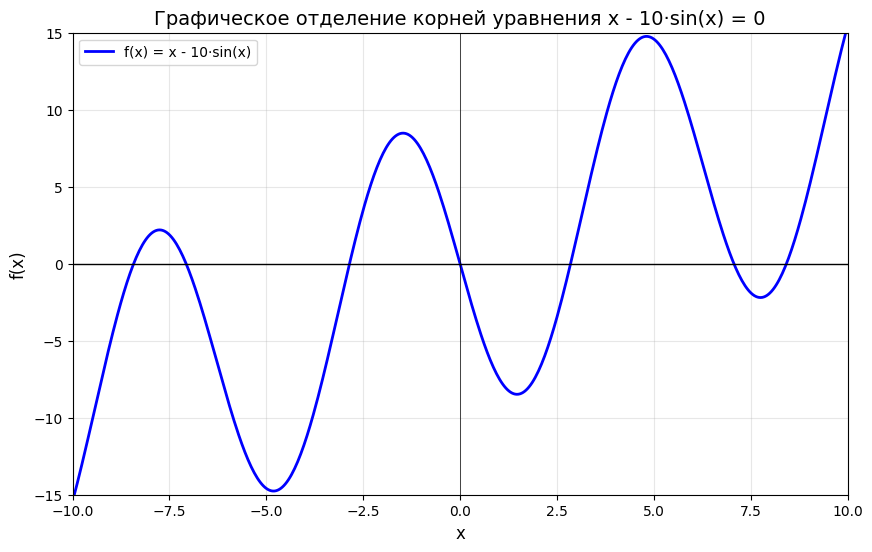


Найденные интервалы, содержащие корни:
Корень 1: [-8.44, -8.40]
Корень 2: [-7.07, -7.03]
Корень 3: [-2.87, -2.83]
Корень 4: [-0.02, 0.02]
Корень 5: [2.83, 2.87]
Корень 6: [7.03, 7.07]
Корень 7: [8.40, 8.44]

Для дальнейших вычислений выбран корень на отрезке [2.5, 3.0]
Значения функции на концах: f(2.5) = -3.4847, f(3.0) = 1.5888

ЗАДАНИЕ 2: Метод половинного деления
Начальный отрезок: [2.5000, 3.0000]
Требуемая точность: 0.001
------------------------------------------------------------
Итерация |     a     |     c     |     b     |   f(c)    |  b-a
------------------------------------------------------------
       1 |  2.5000 |  2.7500 |  3.0000 |  -1.0666 | 0.5000
       2 |  2.7500 |  2.8750 |  3.0000 |   0.2405 | 0.2500
       3 |  2.7500 |  2.8125 |  2.8750 |  -0.4193 | 0.1250
       4 |  2.8125 |  2.8438 |  2.8750 |  -0.0908 | 0.0625
       5 |  2.8438 |  2.8594 |  2.8750 |   0.0745 | 0.0312
       6 |  2.8438 |  2.8516 |  2.8594 |  -0.0082 | 0.0156
       7 |  2.8516 |  2.855

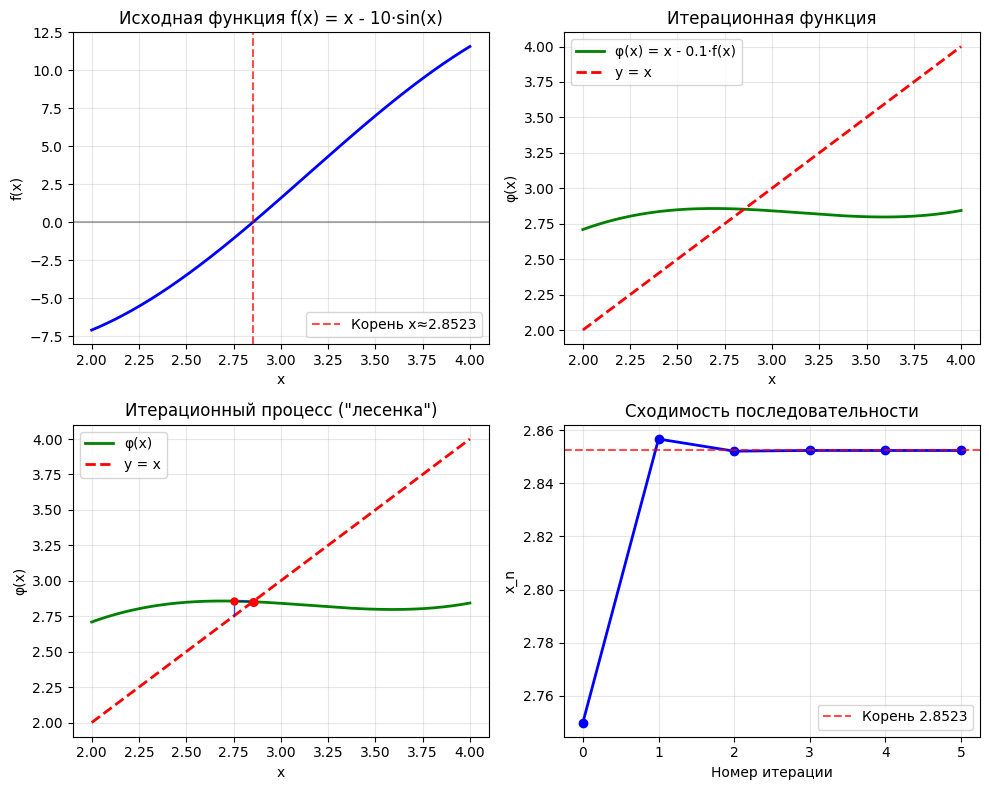


СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Метод                     | Корень       | Итерации   | f(корень)      
----------------------------------------------------------------------
Половинного деления       | 2.852051     | 9          | -0.00308119    
Простой итерации          | 2.85234195   | 5          | 0.00000054     


In [2]:

"""Вариант 2: Решение уравнения x - 10*sin(x) = 0"""

import math
import numpy as np
import matplotlib.pyplot as plt

# Определяем функцию для нашего варианта
def f(x):
    """
    Исходная функция f(x) = x - 10*sin(x)
    Найдем корни этого уравнения
    """
    return x - 10 * math.sin(x)


# === Задание 1 ===
# Отделение корней графическим методом

print("=" * 60)
print("ВАРИАНТ 2: Отделение корней уравнения x - 10·sin(x) = 0")
print("=" * 60)

# Создаем массив точек для построения графика
x_koord = np.linspace(-10, 10, 500)
y_znacheniya = [f(x) for x in x_koord]

# Построение графика для отделения корней
plt.figure(figsize=(10, 6))
plt.plot(x_koord, y_znacheniya, 'b-', linewidth=2, label='f(x) = x - 10·sin(x)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)  # Горизонтальная ось
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)  # Вертикальная ось
plt.grid(True, alpha=0.3)
plt.title('Графическое отделение корней уравнения x - 10·sin(x) = 0', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.xlim(-10, 10)
plt.ylim(-15, 15)
plt.legend()
plt.show()

# Находим интервалы, где функция меняет знак (корни)
korni_intervaly = []
for i in range(len(x_koord) - 1):
    # Если значения функции на концах отрезка имеют разные знаки
    if y_znacheniya[i] * y_znacheniya[i+1] < 0:
        korni_intervaly.append((x_koord[i], x_koord[i+1]))

print("\nНайденные интервалы, содержащие корни:")
for i, (leviy, praviy) in enumerate(korni_intervaly):
    print(f"Корень {i+1}: [{leviy:.2f}, {praviy:.2f}]")

# Выбираем один корень для дальнейших вычислений
# Возьмем корень в районе x = 2.5-3.0
a_nach = 2.5
b_nach = 3.0
print(f"\nДля дальнейших вычислений выбран корень на отрезке [{a_nach}, {b_nach}]")
print(f"Значения функции на концах: f({a_nach}) = {f(a_nach):.4f}, f({b_nach}) = {f(b_nach):.4f}")


# === Задание 2 ===
# Метод половинного деления (бисекции)

print("\n" + "=" * 60)
print("ЗАДАНИЕ 2: Метод половинного деления")
print("=" * 60)

# Параметры метода
levaya_granica = a_nach
pravaya_granica = b_nach
tochnost = 0.001  # Точность 10^-3
iteracii = 0

# Сохраняем начальные значения для вывода
a_tekushiy = levaya_granica
b_tekushiy = pravaya_granica

print(f"Начальный отрезок: [{a_tekushiy:.4f}, {b_tekushiy:.4f}]")
print(f"Требуемая точность: {tochnost}")
print("-" * 60)
print("Итерация |     a     |     c     |     b     |   f(c)    |  b-a")
print("-" * 60)

# Выполняем метод половинного деления
while (b_tekushiy - a_tekushiy) > tochnost:
    # Находим середину отрезка
    seredina = (a_tekushiy + b_tekushiy) / 2
    znachenie_v_seredine = f(seredina)
    
    # Выводим информацию о текущей итерации
    print(f"{iteracii+1:8d} | {a_tekushiy:7.4f} | {seredina:7.4f} | "
          f"{b_tekushiy:7.4f} | {znachenie_v_seredine:8.4f} | {b_tekushiy - a_tekushiy:.4f}")
    
    # Определяем, в какой половине находится корень
    if f(a_tekushiy) * znachenie_v_seredine <= 0:
        b_tekushiy = seredina  # Корень в левой половине
    else:
        a_tekushiy = seredina  # Корень в правой половине
    
    iteracii += 1

# Вычисляем приближенное значение корня
priblizhennyy_koren = (a_tekushiy + b_tekushiy) / 2

print("-" * 60)
print(f"\nРезультат метода половинного деления:")
print(f"Приближенное значение корня: x = {priblizhennyy_koren:.6f}")
print(f"Количество итераций: {iteracii}")
print(f"Проверка: f({priblizhennyy_koren:.6f}) = {f(priblizhennyy_koren):.8f}")


# === Задание 3 ===
# Метод простой итерации

print("\n" + "=" * 60)
print("ЗАДАНИЕ 3: Метод простой итерации")
print("=" * 60)

# Для метода итераций нужно преобразовать уравнение x - 10*sin(x) = 0 к виду x = φ(x)
# Можно использовать: x = arcsin(x/10) или x = 10*sin(x)
# Но arcsin(x/10) определен только при |x| ≤ 10, и производная может быть большой.
# Используем: x = 10*sin(x) с преобразованием для сходимости.

# Подберем параметр λ для обеспечения сходимости |φ'(x)| < 1
# φ(x) = x + λ * f(x)
# φ'(x) = 1 + λ * f'(x) = 1 + λ * (1 - 10*cos(x))
# Для сходимости нужно, чтобы |1 + λ*(1 - 10*cos(x))| < 1
# Для x ≈ 2.5-3.0, cos(x) ≈ -0.8..-0.9, тогда f'(x) = 1 - 10*cos(x) ≈ 9-10
# Возьмем λ = -0.1 (отрицательное, так как f'(x) положительная и большая)

lambda_param = -0.1  # Параметр для обеспечения сходимости

def phi_iter(x):
    """Итерационная функция: x_{n+1} = x + λ * f(x)"""
    return x + lambda_param * f(x)

# Выбираем начальное приближение из найденного интервала
x_nachalnoe = (a_nach + b_nach) / 2
x_tekushiy = x_nachalnoe
tochnost_iter = 0.000001  # Точность 10^-6
iteracii_iter = 0
max_iteraciy = 100

print(f"Итерационная функция: φ(x) = x + ({lambda_param}) * (x - 10·sin(x))")
print(f"Начальное приближение: x₀ = {x_tekushiy:.6f}")
print(f"Требуемая точность: {tochnost_iter}")
print("-" * 70)
print("Итерация |     x_n     |    x_{n+1}    |  |x_{n+1} - x_n|  |   f(x_{n+1})")
print("-" * 70)

# Выполняем итерационный процесс
for i in range(max_iteraciy):
    x_noviy = phi_iter(x_tekushiy)
    raznica = abs(x_noviy - x_tekushiy)
    
    print(f"{i+1:8d} | {x_tekushiy:10.6f} | {x_noviy:10.6f} | {raznica:16.8f} | {f(x_noviy):12.8f}")
    
    if raznica < tochnost_iter:
        koren_iter = x_noviy
        iteracii_iter = i + 1
        break
    
    x_tekushiy = x_noviy

print("-" * 70)
print(f"\nРезультат метода простой итерации:")
print(f"Приближенное значение корня: x = {koren_iter:.8f}")
print(f"Количество итераций: {iteracii_iter}")
print(f"Проверка: f({koren_iter:.8f}) = {f(koren_iter):.8f}")

# Дополнительно: визуализация сходимости итерационного процесса
print("\n" + "=" * 60)
print("Визуализация сходимости метода итераций")
print("=" * 60)

# Строим график итерационной функции
x_graf = np.linspace(2, 4, 200)
phi_graf = [x + lambda_param * (x - 10*math.sin(x)) for x in x_graf]

plt.figure(figsize=(10, 8))

# Подграфик 1: Исходная функция
plt.subplot(2, 2, 1)
y_graf = [f(x) for x in x_graf]
plt.plot(x_graf, y_graf, 'b-', linewidth=2)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=koren_iter, color='r', linestyle='--', alpha=0.7, label=f'Корень x≈{koren_iter:.4f}')
plt.grid(True, alpha=0.3)
plt.title('Исходная функция f(x) = x - 10·sin(x)')
plt.xlabel('x'), plt.ylabel('f(x)')
plt.legend()

# Подграфик 2: Итерационная функция и прямая y=x
plt.subplot(2, 2, 2)
plt.plot(x_graf, phi_graf, 'g-', linewidth=2, label='φ(x) = x - 0.1·f(x)')
plt.plot(x_graf, x_graf, 'r--', linewidth=2, label='y = x')
plt.grid(True, alpha=0.3)
plt.title('Итерационная функция')
plt.xlabel('x'), plt.ylabel('φ(x)')
plt.legend()

# Подграфик 3: Сходимость итераций (лесенка)
plt.subplot(2, 2, 3)
plt.plot(x_graf, phi_graf, 'g-', linewidth=2, label='φ(x)')
plt.plot(x_graf, x_graf, 'r--', linewidth=2, label='y = x')

# Строим "лесенку" для демонстрации итераций
x_iter = x_nachalnoe
x_tochki = [x_iter]
for _ in range(5):  # Покажем первые 5 итераций
    y_iter = phi_iter(x_iter)
    plt.plot([x_iter, x_iter], [x_iter, y_iter], 'b-', linewidth=1, alpha=0.7)
    plt.plot([x_iter, y_iter], [y_iter, y_iter], 'b-', linewidth=1, alpha=0.7)
    plt.plot(x_iter, phi_iter(x_iter), 'ro', markersize=5)
    x_iter = y_iter
    x_tochki.append(x_iter)

plt.grid(True, alpha=0.3)
plt.title('Итерационный процесс ("лесенка")')
plt.xlabel('x'), plt.ylabel('φ(x)')
plt.legend()

# Подграфик 4: Значения на итерациях
plt.subplot(2, 2, 4)
plt.plot(range(len(x_tochki)), x_tochki, 'bo-', linewidth=2, markersize=6)
plt.axhline(y=koren_iter, color='r', linestyle='--', alpha=0.7, label=f'Корень {koren_iter:.4f}')
plt.grid(True, alpha=0.3)
plt.title('Сходимость последовательности')
plt.xlabel('Номер итерации'), plt.ylabel('x_n')
plt.legend()

plt.tight_layout()
plt.show()

# Сравнение результатов разных методов
print("\n" + "=" * 60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 60)
print(f"{'Метод':<25} | {'Корень':<12} | {'Итерации':<10} | {'f(корень)':<15}")
print("-" * 70)
print(f"{'Половинного деления':<25} | {priblizhennyy_koren:<12.6f} | {iteracii:<10} | {f(priblizhennyy_koren):<15.8f}")
print(f"{'Простой итерации':<25} | {koren_iter:<12.8f} | {iteracii_iter:<10} | {f(koren_iter):<15.8f}")
print("=" * 60)